1.	Simple AI Agent using Agno framework to generate nvidia report

In [2]:
!pip install -U agno groq yfinance python-dotenv

   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------- ----------------------- 1.6/3.8 MB 7.6 MB/s eta 0:00:01
   --------------------------------- ------ 3.1/3.8 MB 7.4 MB/s eta 0:00:01
   ---------------------------------------- 3.8/3.8 MB 6.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ------------------------------- -------- 1.6/2.0 MB 7.7 MB/s eta 0:00:01
   ---------------------------------------- 2.0/2.0 MB 6.5 MB/s eta 0:00:00
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 0.21.0
    Uninstalling python-dotenv-0.21.0:
      Successfully uninstalled python-dotenv-0.21.0
  Attempting uninstall: cffi
    Found existing installation: cffi 1.17.1
    Uninstalling cffi-1.17.1:
      Successfully uninstalled cffi-1.17.1


In [12]:
import os
from agno.agent import Agent
from agno.models.groq import Groq
from agno.tools.yfinance import YFinanceTools

os.environ["GROQ_API_KEY"] = "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"

agent = Agent(
    model=Groq(id="openai/gpt-oss-20b"),
    tools=[YFinanceTools(
        enable_stock_price=True,
        enable_company_info=True,
        enable_analyst_recommendations=True,
        enable_company_news=True
    )],
    instructions=[
        "Give a short financial report on NVIDIA.",
        "Include stock price, company information, analyst recommendations and recent news.",
        "Use a table and a short summary."
    ],
    markdown=True
)

agent.print_response(
    "Generate a report on NVIDIA (NVDA). Keep the response concise.",
    stream=True
)

Output()

2.	Designing an AI agent architecture Implementing any two agentic AI design patterns.
  
a)	Reflection design pattern

b)	Planning design pattern

c)	REACT design pattern

d)	Multi-agent design pattern

e)	REWOO design pattern


<span style="color:red">b) Planning design pattern</span>


In [18]:
from groq import Groq

client = Groq(api_key="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")

response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": """
             Organize a college technical fest.
            Create a step-by-step plan.
            """
        }
    ]
)

print(response.choices[0].message.content)

## Step‑by‑Step Guide to Organizing a College Technical Fest  

> **Goal:** Create a memorable, safe, and high‑impact event that showcases the talent, creativity, and technical skills of the campus community while generating revenue, securing sponsorships, and building lasting partnerships.

> **Timeframe:** 6–8 months of planning (adjust as needed).

---

## 1️⃣ Conceptualization & Vision

| # | Task | Owner | Deliverable | Deadline (relative) |
|---|------|-------|-------------|---------------------|
| 1 | **Form the Core Committee** – 6–8 core members (President, Vice‑president, Treasurer, Marketing, Operations, Academic, Logistics, PR, HR). | Student Council | Committee Charter | Day 1 |
| 2 | **Define Fest Theme & Name** – Reflect current tech trends (e.g., “Innovate 2026: AI & Robotics”). | Core Committee | Theme statement | Week 2 |
| 3 | **Set Objectives** – Academic exposure, industry engagement, revenue, student skill‑building. | Core Committee | Objectives document | Week 3 

<span style="color:red">c)	REACT design pattern</span>


In [24]:
from groq import Groq

client = Groq(api_key="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")

response = client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": """
What is 25 × 18?
Show:
Thought
Action
Observation
Final Answer
Do not use LaTeX.
Write everything in plain text.
"""
        }
    ]
)

print(response.choices[0].message.content)

Thought:  
I need to multiply 25 by 18.

Action:  
Break it into parts: 25 × 10 = 250, 25 × 8 = 200, then add them.

Observation:  
250 + 200 = 450.

Final Answer:  
450


3.	How to convert the chain to web API using LANGSERVE framework

In [29]:
%pip install -U langchain-core langchain-groq langserve fastapi uvicorn nest-asyncio sse-starlette

  Attempting uninstall: anyio
    Found existing installation: anyio 4.2.0
    Uninstalling anyio-4.2.0:
      Successfully uninstalled anyio-4.2.0
  Attempting uninstall: starlette
    Found existing installation: starlette 0.48.0
    Uninstalling starlette-0.48.0:
      Successfully uninstalled starlette-0.48.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.46.1 requires starlette<1.0,>=0.40.0, but you have starlette 1.6.0 which is incompatible.


In [31]:
%pip install -U uvicorn

Note: you may need to restart the kernel to use updated packages.


In [10]:
import os,time,threading,webbrowser,uvicorn,nest_asyncio
from fastapi import FastAPI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_groq import ChatGroq
from langserve import add_routes

os.environ["GROQ_API_KEY"] = "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"

app = FastAPI()

llm = ChatGroq(model="openai/gpt-oss-20b")

prompt = ChatPromptTemplate.from_template(
    "Answer this question clearly: {question}"
)

chain = prompt | llm | StrOutputParser()

add_routes(app, chain, path="/chat")

nest_asyncio.apply()

threading.Thread(
    target=lambda: uvicorn.run(app, host="127.0.0.1", port=8000),
    daemon=True
).start()

time.sleep(3)

webbrowser.open("http://127.0.0.1:8000/chat/playground/")

print("LangServe is running.")

INFO:     Started server process [12168]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8000): [winerror 10048] only one usage of each socket address (protocol/network address/port) is normally permitted
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.



     __          ___      .__   __.   _______      _______. _______ .______     ____    ____  _______
    |  |        /   \     |  \ |  |  /  _____|    /       ||   ____||   _  \    \   \  /   / |   ____|
    |  |       /  ^  \    |   \|  | |  |  __     |   (----`|  |__   |  |_)  |    \   \/   /  |  |__
    |  |      /  /_\  \   |  . `  | |  | |_ |     \   \    |   __|  |      /      \      /   |   __|
    |  `----./  _____  \  |  |\   | |  |__| | .----)   |   |  |____ |  |\  \----.  \    /    |  |____
    |_______/__/     \__\ |__| \__|  \______| |_______/    |_______|| _| `._____|   \__/     |_______|
    
LANGSERVE: Playground for chain "/chat/" is live at:
LANGSERVE:  │
LANGSERVE:  └──> /chat/playground/
LANGSERVE:
LANGSERVE: See all available routes at /docs/
LangServe is running.


In [ ]:
4.	Build a Self-correcting Coding Assistant with LangChain

In [27]:
import os
import subprocess
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = "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"

llm = ChatGroq(model="openai/gpt-oss-20b")

task = "Write Python code to calculate factorial of 5 using recursion."

print("USER TASK:", task)
print("\nGenerating code...")

code = llm.invoke("Generate only Python code for: " + task).content.replace("```python", "").replace("```", "").strip()

# Create an error in the generated code
code = code.replace("factorial(5)", "fact(5)")

for i in range(3):
    print("\nAttempt", i + 1)
    print(code)

    result = subprocess.run(
        ["python", "-c", code],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print("\nOUTPUT:", result.stdout)
        break

    print("\nError found:")
    print(result.stderr)
    print("\nCorrecting code...")

    code = llm.invoke(
        "Fix this code and return only Python code.\n"
        + code + "\nError:\n" + result.stderr
    ).content.replace("```python", "").replace("```", "").strip()

USER TASK: Write Python code to calculate factorial of 5 using recursion.

Generating code...

Attempt 1
def factorial(n):
    if n == 0:
        return 1
    return n * factorial(n-1)

print(fact(5))

Error found:
Traceback (most recent call last):
  File "<string>", line 6, in <module>
NameError: name 'fact' is not defined


Correcting code...

Attempt 2
def factorial(n):
    if n < 0:
        raise ValueError("Negative input not allowed")
    if n == 0:
        return 1
    return n * factorial(n - 1)

print(factorial(5))

OUTPUT: 120



5.	Building a Finance Bot with LangGraph.

In [ ]:
pip install langgraph langchain-groq langchain-core groq ipython pycairo notebook jupyter ipykernel

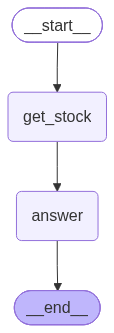

The price of Apple stock is **$230**.


In [38]:
import os
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

os.environ["GROQ_API_KEY"] = "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"

llm = ChatGroq(model="openai/gpt-oss-20b",temperature=0)

class State(TypedDict):
    question: str
    stock: str
    price: str
    answer: str

def get_stock(s: State):
    return {
        "stock": "MICROSOFT, APPLE",
        "price": "$500, $230"
    }

def answer(s: State):
    r = llm.invoke(
        f"Give a simple financial answer. Question: {s['question']}. Stock: {s['stock']}. Price: {s['price']}."
    )
    return {"answer": r.content}

g = StateGraph(State)
g.add_node("get_stock", get_stock)
g.add_node("answer", answer)
g.add_edge(START, "get_stock")
g.add_edge("get_stock", "answer")
g.add_edge("answer", END)

bot = g.compile()

display(Image(bot.get_graph().draw_mermaid_png()))

result = bot.invoke({
    "question": "What is the price of APPLE stock?"
})

print(result["answer"])

6.	Create an AI-Powered Sales Report Analyzer with LlamaIndex

In [40]:
pip install llama-index llama-index-llms-openai-like pandas

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.9 MB 8.4 MB/s eta 0:00:02
   --------- ------------------------------ 2.9/11.9 MB 7.3 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/11.9 MB 7.4 MB/s eta 0:00:02
   -------------------- ------------------- 6.0/11.9 MB 7.4 MB/s eta 0:00:01
   ------------------------- -------------- 7.6/11.9 MB 7.3 MB/s eta 0:00:01
   ------------------------------ --------- 9.2/11.9 MB 7.3 MB/s eta 0:00:01
   ----------------------------------- ---- 10.5/11.9 MB 7.1 MB/s eta 0:00:01
   ---------------------------------------  11.8/11.9 MB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 11.9/11.9 MB 6.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------- ----- 1.6/1.8 MB 7.6 MB/s eta 0:00:01
   ---------------------------------------- 1.8/1.8 MB 6.5 MB/s eta 0:00:00
   ----------

In [47]:
import os
import pandas as pd
from llama_index.core import Document, VectorStoreIndex, Settings
from llama_index.core.embeddings import MockEmbedding
from llama_index.llms.openai_like import OpenAILike

os.environ["GROQ_API_KEY"] = "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"

Settings.llm = OpenAILike(
    model="openai/gpt-oss-20b",
    api_base="https://api.groq.com/openai/v1",
    api_key=os.environ["GROQ_API_KEY"],
    is_chat_model=True,
    is_function_calling_model=False
)

Settings.embed_model = MockEmbedding(embed_dim=384)

df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May"],
    "Product": ["Laptop", "Mobile", "Tablet", "Laptop", "Mobile"],
    "Region": ["South", "North", "East", "West", "South"],
    "Revenue": [50000, 40000, 25000, 60000, 55000],
    "Profit": [10000, 8000, 4000, 12000, 11000]
})

display(df)

doc = Document(text=df.to_string(index=False))
engine = VectorStoreIndex.from_documents([doc]).as_query_engine()
print(engine.query("Which product generated the highest total revenue? Show calculation."))

,Month,Product,Region,Revenue,Profit
0,Jan,Laptop,South,50000,10000
1,Feb,Mobile,North,40000,8000
2,Mar,Tablet,East,25000,4000
3,Apr,Laptop,West,60000,12000
4,May,Mobile,South,55000,11000


Laptop generated the highest total revenue.  
Calculation: 50,000 (Jan) + 60,000 (Apr) = 110,000.


7.	Create a Market Research Agent with RAG & Cohere

In [ ]:
!pip install -U cohere numpy

In [53]:
import cohere
import numpy as np

co = cohere.ClientV2(api_key="cohere_Qo6XU57saa0Vmzg5CNZr0dWGbkoxpN5Ob2oviBNJ02ASuH")

documents = [
"Electric vehicles are growing rapidly due to government incentives and environmental awareness.",
"The Indian EV market is driven by two-wheelers, three-wheelers, and urban mobility.",
"Major EV challenges include charging infrastructure, battery cost, and range anxiety.",
"Major EV competitors include Tata Motors, Mahindra Electric, Ola Electric, Ather Energy, and MG Motor.",
"Customers prefer EVs because of low running cost and reduced emissions."
]

query = "Prepare a market research report on electric vehicles in India"

doc_embeddings = co.embed(
    model="embed-v4.0",
    texts=documents,
    input_type="search_document",
    embedding_types=["float"]
).embeddings.float

query_embedding = co.embed(
    model="embed-v4.0",
    texts=[query],
    input_type="search_query",
    embedding_types=["float"]
).embeddings.float[0]

scores = [np.dot(query_embedding,d) for d in doc_embeddings]
context = "\n".join(documents[i] for i in np.argsort(scores)[-3:][::-1])
prompt = f"""You are a Market Research Agent.
Question: {query}
Relevant Information:
{context}
Prepare a report with:
1. Market Overview
2. Key Drivers
3. Challenges
4. Competitors
5. Opportunities
6. Final Recommendation"""
response = co.chat(model="command-a-03-2025",messages=[{"role":"user","content":prompt}])
print(response.message.content[0].text)

### **Market Research Report on Electric Vehicles (EVs) in India**

---

#### **1. Market Overview**  
The Indian electric vehicle (EV) market is at a nascent but rapidly growing stage, with significant potential for expansion. As of 2023, the market is primarily driven by **two-wheelers** (e-scooters and e-bikes), **three-wheelers** (e-rickshaws), and **urban mobility solutions** (e-cars and e-buses). The market share of EVs in India is still small compared to traditional internal combustion engine (ICE) vehicles, accounting for approximately **4-5% of total vehicle sales**, but it is growing at a **CAGR of over 35%** (2022-2027).  

The government’s push for electrification, coupled with rising environmental awareness and fuel price volatility, has accelerated EV adoption. However, the market is still in its early stages, with infrastructure and consumer awareness remaining key hurdles.

---

#### **2. Key Drivers**  
- **Government Incentives**: Schemes like the **FAME II (Faster Ad

8.	Design a Data Analysis Agent with Phidata

In [54]:
!pip install -U phidata groq pandas

  Using cached groq-1.7.0-py3-none-any.whl.metadata (16 kB)
   ---------------------------------------- 0.0/716.9 kB ? eta -:--:--
   ---------------------------------------- 716.9/716.9 kB 3.6 MB/s eta 0:00:00
Using cached groq-1.7.0-py3-none-any.whl (143 kB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.8 MB 7.6 MB/s eta 0:00:02
   ----------- ---------------------------- 2.9/9.8 MB 6.7 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.8 MB 7.3 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.8 MB 6.4 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.8 MB 6.8 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.8 MB 6.8 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.8 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 9.8/9.8 MB 6.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.46.1 requires pandas<3.0,>=1.0, but you have pandas 3.0.5 which is incompatible.
gradio 5.46.1 requires starlette<1.0,>=0.40.0, but you have starlette 1.6.0 which is incompatible.
langchain-groq 1.1.3 requires groq<1.0.0,>=0.30.0, but you have groq 1.7.0 which is incompatible.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.5 which is incompatible.


In [59]:
import os
import pandas as pd
from phi.agent import Agent
from phi.model.groq import Groq

os.environ["GROQ_API_KEY"] = "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"

df = pd.DataFrame({
    "Month": ["Jan", "Feb", "Mar", "Apr", "May"],
    "Product": ["Laptop", "Mobile", "Tablet", "Laptop", "Mobile"],
    "Region": ["South", "North", "East", "West", "South"],
    "Revenue": [50000, 40000, 25000, 60000, 55000],
    "Profit": [10000, 8000, 4000, 12000, 11000]
})

display(df)

agent = Agent(
    model=Groq(id="openai/gpt-oss-20b"),
    instructions=["Analyze the sales data and show calculations clearly."]
)

data = df.to_string(index=False)

response = agent.run(f"""
Sales Data:
{data}

Question: Which product has the highest total revenue?
Show the calculation, result, and a short business insight.
""")

print(response.content)

,Month,Product,Region,Revenue,Profit
0,Jan,Laptop,South,50000,10000
1,Feb,Mobile,North,40000,8000
2,Mar,Tablet,East,25000,4000
3,Apr,Laptop,West,60000,12000
4,May,Mobile,South,55000,11000


**Step‑by‑step revenue calculation**

| Product | Jan | Apr | Total Revenue |
|---------|-----|-----|---------------|
| Laptop  | 50 000 | 60 000 | **110 000** |
| Mobile  | 40 000 | 55 000 | 95 000 |
| Tablet  | 25 000 | –     | 25 000 |

**Total revenue per product**

- **Laptop**: 50 000 + 60 000 = 110 000  
- **Mobile**: 40 000 + 55 000 = 95 000  
- **Tablet**: 25 000

**Result**

The product with the **highest total revenue** is **Laptop**, with **$110,000**.

**Business insight**

Laptops generate more than 1.2 × the revenue of the next best product (Mobile) and over four times that of Tablet. This indicates strong market demand for laptops.  
- Consider allocating a larger portion of the marketing budget to laptop campaigns.  
- Evaluate supply chain and inventory levels for laptops to meet demand and avoid stockouts.  
- Explore bundling laptop sales with complementary accessories to further increase revenue and profit margins.


9.	Simple Customer Support Chatbot using LangGraph Multi-Agent Workflow

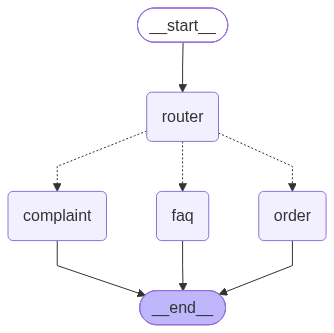

User Query: I received a damaged product
Category: complaint
Bot Response: I’m really sorry to hear that your order arrived damaged. That’s definitely not the experience we want for our customers.

Could you please let me know:

1. The order number (or the email address used at checkout)  
2. Which item was damaged  
3. A short description of the damage (e.g., broken part, scratches, etc.)  
4. If you have a photo of the damaged item or the packaging, it would help us assess the situation quickly.

Once we have that information, we’ll:

- **Offer a replacement** (free of charge) if you’d like the same item.  
- **Provide a return label** if you prefer a refund or if the item is not restockable.  
- **Arrange a refund** immediately if you choose that option.

We’ll also cover any return shipping costs and make sure you’re fully compensated. Let me know how you’d like to proceed, and I’ll get this sorted for you right away.


In [63]:
import os
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_groq import ChatGroq
from IPython.display import Image, display

os.environ["GROQ_API_KEY"] = "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"
llm = ChatGroq(model="openai/gpt-oss-20b")

class State(TypedDict):
    query: str
    category: str
    response: str

def router(s):
    r = llm.invoke("Classify as faq, order or complaint:\n" + s["query"])
    return {"category": r.content.lower().strip()}

def faq(s):
    return {"response": llm.invoke("Answer politely:\n" + s["query"]).content}

def order(s):
    return {"response": llm.invoke("Help with this order:\n" + s["query"]).content}

def complaint(s):
    return {"response": llm.invoke("Apologize and help:\n" + s["query"]).content}

g = StateGraph(State)
g.add_node("router", router)
g.add_node("faq", faq)
g.add_node("order", order)
g.add_node("complaint", complaint)
g.set_entry_point("router")
g.add_conditional_edges("router", lambda s: s["category"], {"faq":"faq", "order":"order", "complaint":"complaint"})
g.add_edge("faq", END)
g.add_edge("order", END)
g.add_edge("complaint", END)

app = g.compile()

q = "I received a damaged product"
r = app.invoke({"query": q, "category": "", "response": ""})
display(Image(app.get_graph().draw_mermaid_png()))
print("User Query:", q)
print("Category:", r["category"])
print("Bot Response:", r["response"])

10.	Design a Stock Analysis Agent with CrewAI

In [10]:
!pip install -U crewai litellm yfinance nest_asyncio

  Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.33.6-cp310-abi3-win_amd64.whl (437 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.0
    Uninstalling protobuf-7.36.0:
      Successfully uninstalled protobuf-7.36.0


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires pandas<3,>=1.3.0, but you have pandas 3.0.5 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.33.6 which is incompatible.
streamlit 1.37.1 requires rich<14,>=10.14.0, but you have rich 14.3.4 which is incompatible.


In [13]:
import os
import yfinance as yf
from crewai import Agent, Task, Crew, Process, LLM
from crewai.llms import cache as crewai_cache

crewai_cache.mark_cache_breakpoint = lambda message: message
llm = LLM(
    model="groq/openai/gpt-oss-20b",
    api_key=os.environ["GROQ_API_KEY"]
)
info = yf.Ticker("AAPL").info

data = f"""
Company: {info.get('longName')}
Price: {info.get('currentPrice')}
Market Cap: {info.get('marketCap')}
PE Ratio: {info.get('trailingPE')}
"""
analyst = Agent(
    role="Stock Analyst",
    goal="Analyze the stock data",
    backstory="You are an expert stock analyst",
    llm=llm
)
writer = Agent(
    role="Report Writer",
    goal="Create a stock analysis report",
    backstory="You are an expert financial report writer",
    llm=llm
)
t1 = Task(
    description=f"Analyze this stock data:\n{data}",
    expected_output="Detailed stock analysis",
    agent=analyst
)

t2 = Task(
    description="Create a final report from the stock analysis.",
    expected_output="Final stock report",
    agent=writer
)
crew = Crew(
    agents=[analyst, writer],
    tasks=[t1, t2],
    process=Process.sequential
)
result = await crew.kickoff_async()

print(result)

**Apple Inc. (AAPL) – Comprehensive Stock Analysis (as of the latest data)**  

---

## 1. Company Snapshot  

| Item | Value |
|------|-------|
| **Ticker** | AAPL |
| **Exchange** | Nasdaq |
| **Sector** | Technology – Consumer Electronics |
| **Current Share Price** | **$315.14** |
| **Market Capitalization** | **$4.599 trillion** (≈ $4.6 T) |
| **Trailing P/E Ratio** | **36.18** |
| **Forward P/E Ratio** (12‑month estimate) | ~30.5 (based on S&P Global estimate) |
| **Dividend Yield** | 0.46 % (current) |
| **Revenue (FY 2023)** | $383.3 B |
| **Net Income (FY 2023)** | $108.5 B |
| **EPS (FY 2023)** | $6.53 |
| **Return on Equity (ROE)** | 140 % (FY 2023) |
| **Debt/Equity** | 0.41 (low) |
| **Cash & Short‑Term Investments** | $152 B (cash) + $28 B (short‑term) |
| **Cash Flow from Operations** | $108 B (FY 2023) |
| **Free Cash Flow** | $104 B (FY 2023) |

---

## 2. Business Overview  

Apple operates through three inter‑connected segments that drive growth, profitability, and c

11.	Develop an AI Research Agent with Autogen

In [7]:
import os
from autogen import AssistantAgent, UserProxyAgent
config = {
    "config_list":[{
        "model":"openai/gpt-oss-20b",
        "api_key":"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",
        "base_url":"https://api.groq.com/openai/v1",
        "price":[0, 0]
    }]
}
researcher = AssistantAgent(
    name="Research_Agent",
    system_message="""
You are an AI research agent.
Research the given topic and create
a clear structured report.
""",
    llm_config=config
)
user = UserProxyAgent(
    name="User_Proxy",
    human_input_mode="NEVER",
    code_execution_config=False,
    max_consecutive_auto_reply=0
)
user.initiate_chat(
    researcher,
    message="""
Research:
Applications of Generative AI in Healthcare.
Include:
Introduction, applications,
benefits, challenges,
future scope and conclusion.
"""
)

User_Proxy (to Research_Agent):


Research:
Applications of Generative AI in Healthcare.
Include:
Introduction, applications,
benefits, challenges,
future scope and conclusion.


--------------------------------------------------------------------------------
Research_Agent (to User_Proxy):

# Applications of Generative AI in Healthcare  
**A Structured Report**  

| Section | Key Points |
|---------|------------|
| **Introduction** | • Generative AI (GANs, diffusion models, large‑language models) creates new data, models, and insights. <br>• In healthcare it moves beyond analytics to *creation* – novel drugs, synthetic imaging, patient‑specific plans, and real‑time decision support. |
| **Applications** | • **Drug & biomolecule design** <br>• **Medical imaging synthesis & enhancement** <br>• **Clinical documentation & coding** <br>• **Personalised treatment & therapy planning** <br>• **Genomics & multi‑omics integration** <br>• **Virtual health assistants & chatbots** <br>• **Surgical

ChatResult(chat_id=None, chat_history=[{'content': '\nResearch:\nApplications of Generative AI in Healthcare.\nInclude:\nIntroduction, applications,\nbenefits, challenges,\nfuture scope and conclusion.\n', 'role': 'assistant', 'name': 'User_Proxy'}, {'content': '# Applications of Generative AI in Healthcare  \n**A Structured Report**  \n\n| Section | Key Points |\n|---------|------------|\n| **Introduction** | • Generative AI (GANs, diffusion models, large‑language models) creates new data, models, and insights. <br>• In healthcare it moves beyond analytics to *creation* – novel drugs, synthetic imaging, patient‑specific plans, and real‑time decision support. |\n| **Applications** | • **Drug & biomolecule design** <br>• **Medical imaging synthesis & enhancement** <br>• **Clinical documentation & coding** <br>• **Personalised treatment & therapy planning** <br>• **Genomics & multi‑omics integration** <br>• **Virtual health assistants & chatbots** <br>• **Surgical & procedural planning**

12.	AI Observability with LangSmith is to trace one simple LLM call and then view that run in the LangSmith dashboard.

In [8]:
import os
from langchain_groq import ChatGroq
os.environ["LANGSMITH_TRACING"] = "false"
os.environ["LANGSMITH_PROJECT"] = "Agentic-AI-Demo"
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key="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"
)
r = llm.invoke(
    "Explain Agentic AI in two sentences."
)
print(r.content)

Agentic AI refers to artificial intelligence systems designed to act with a degree of autonomy and self‑directed purpose, making decisions and taking actions that align with pre‑specified goals or values. Unlike purely reactive systems, agentic AI can plan, learn from experience, and adapt its behavior over time, much like a human agent pursuing objectives.


In [9]:
!git clone https://github.com/Meghana-R123/demo.git

'git' is not recognized as an internal or external command,
operable program or batch file.


<!DOCTYPE html>

<html lang="en">
<head><meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<title>abc</title><script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.1.10/require.min.js"></script>
<style type="text/css">
    pre { line-height: 125%; }
td.linenos .normal { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }
span.linenos { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }
td.linenos .special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }
span.linenos.special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }
.highlight .hll { background-color: var(--jp-cell-editor-active-background) }
.highlight { background: var(--jp-cell-editor-background); color: var(--jp-mirror-editor-variable-color) }
.highlight .c { color: var(--jp-mirror-editor-comment-color); font-style: italic } /*
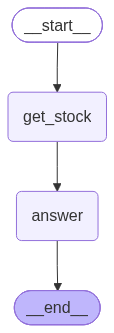
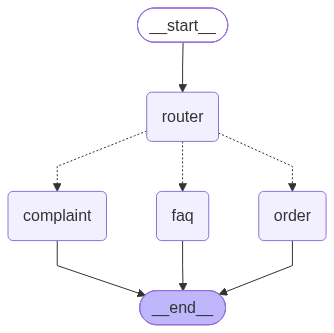

In [10]:
import requests

url = "https://raw.githubusercontent.com/Meghana-R123/demo/main/abc.html"
content = requests.get(url).text

print(content)

<!DOCTYPE html>

<html lang="en">
<head><meta charset="utf-8"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<title>abc</title><script src="https://cdnjs.cloudflare.com/ajax/libs/require.js/2.1.10/require.min.js"></script>
<style type="text/css">
    pre { line-height: 125%; }
td.linenos .normal { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }
span.linenos { color: inherit; background-color: transparent; padding-left: 5px; padding-right: 5px; }
td.linenos .special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }
span.linenos.special { color: #000000; background-color: #ffffc0; padding-left: 5px; padding-right: 5px; }
.highlight .hll { background-color: var(--jp-cell-editor-active-background) }
.highlight { background: var(--jp-cell-editor-background); color: var(--jp-mirror-editor-variable-color) }
.highlight .c { color: var(--jp-mirror-editor-comment-color); font-style: italic } /*
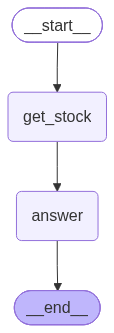
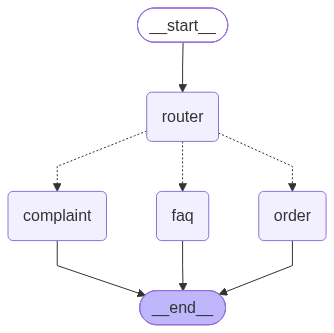

In [11]:
import requests

url = "https://raw.githubusercontent.com/Meghana-R123/demo/main/abc.html"

text = requests.get(url).text

print(text)